# 5.0) Random Forest


- Random Forest é uma melhor do algoritmo de árvores de decisão. 

- Pode competir com redes neurais e LSTM.


Em vez de só usarmos uma árvore de decisão, usaremos várias ou dezenas. Combinar cada uma dessas árvores de decisão. 

Floresta randômica é floresta com um conjunto de muitas árvores. 


### Random Forest

- Ensemble learning (aprendizagem em conjunto)

a) Consultar diversos profissionais para tomar uma decisão.

b) Vários algoritmos juntos para construir um algoritmo mais "forte".

c) Usa a MÉDIA (para REGRESSÃO) ou VOTOS DA MAIORIA (para CLASSIFICAÇÃO) para dar a resposta final.



_classificação (rótulos, exemplo alto, médio e baixo)_

_regressão (preve valores numéricos, como limites de cartão de crédito)_

-------


#### podemos parametrizar o algoritmo, com 3 árvores.


## CUIDADO: colocar muitas árvores de decisão pode causar Overfitting
Se adequando muito a nossa base de dados de treino.



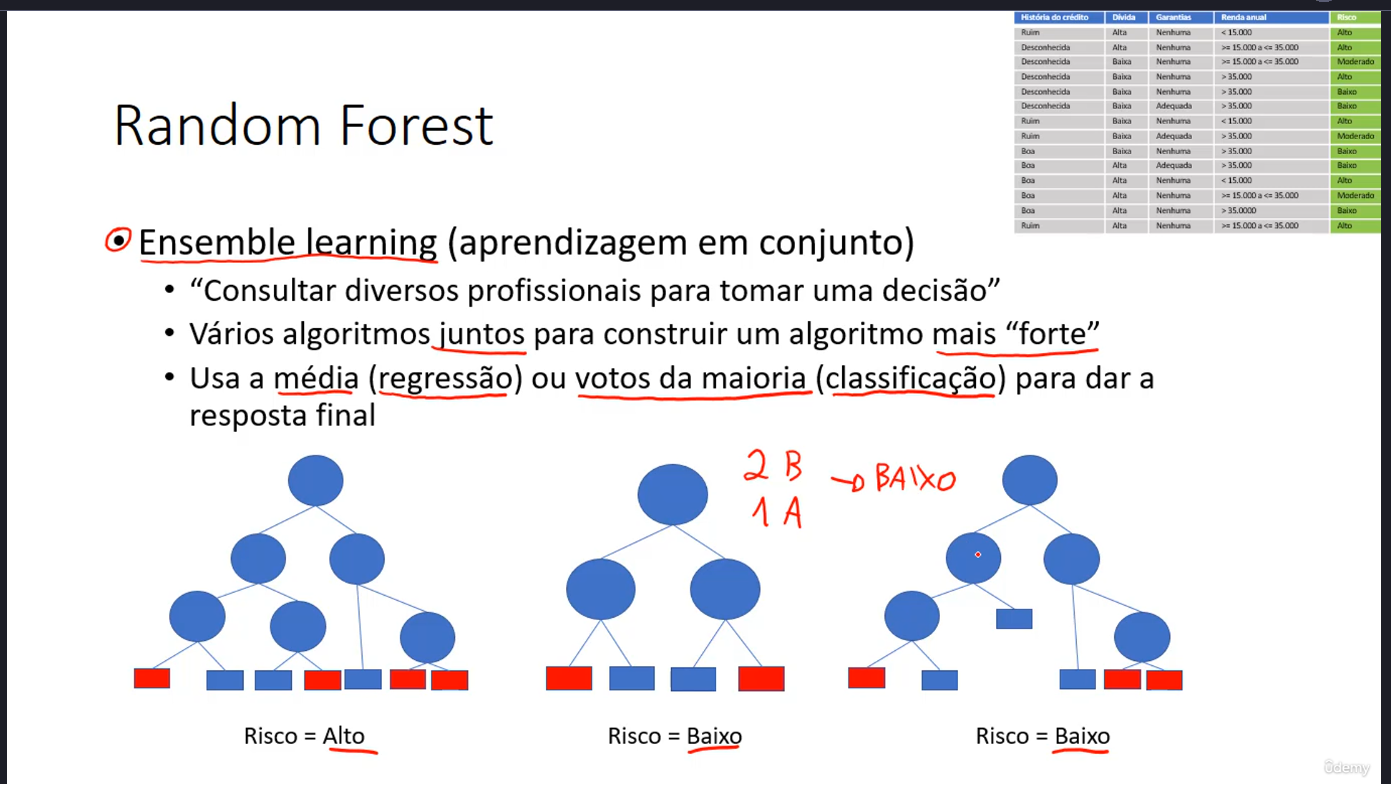


- Random Forest

Escolhe de forma aleatória K (atributos) para comparação da métrica de pureza/impureza (impureza de gini/entropia)

Cálculo de entropia


- K = 3 São 3 atributos ou seja 3 colunas optadas para análise (sendo que temos 4 colunas para decidir o risco)

- Árvores = 3


Random pegará cada atributo diferente (coluna ou variável diferente) em cada árvore. 

Ou seja, de forma aleatória dividem em 3 as colunas(K) para a Árvores. 




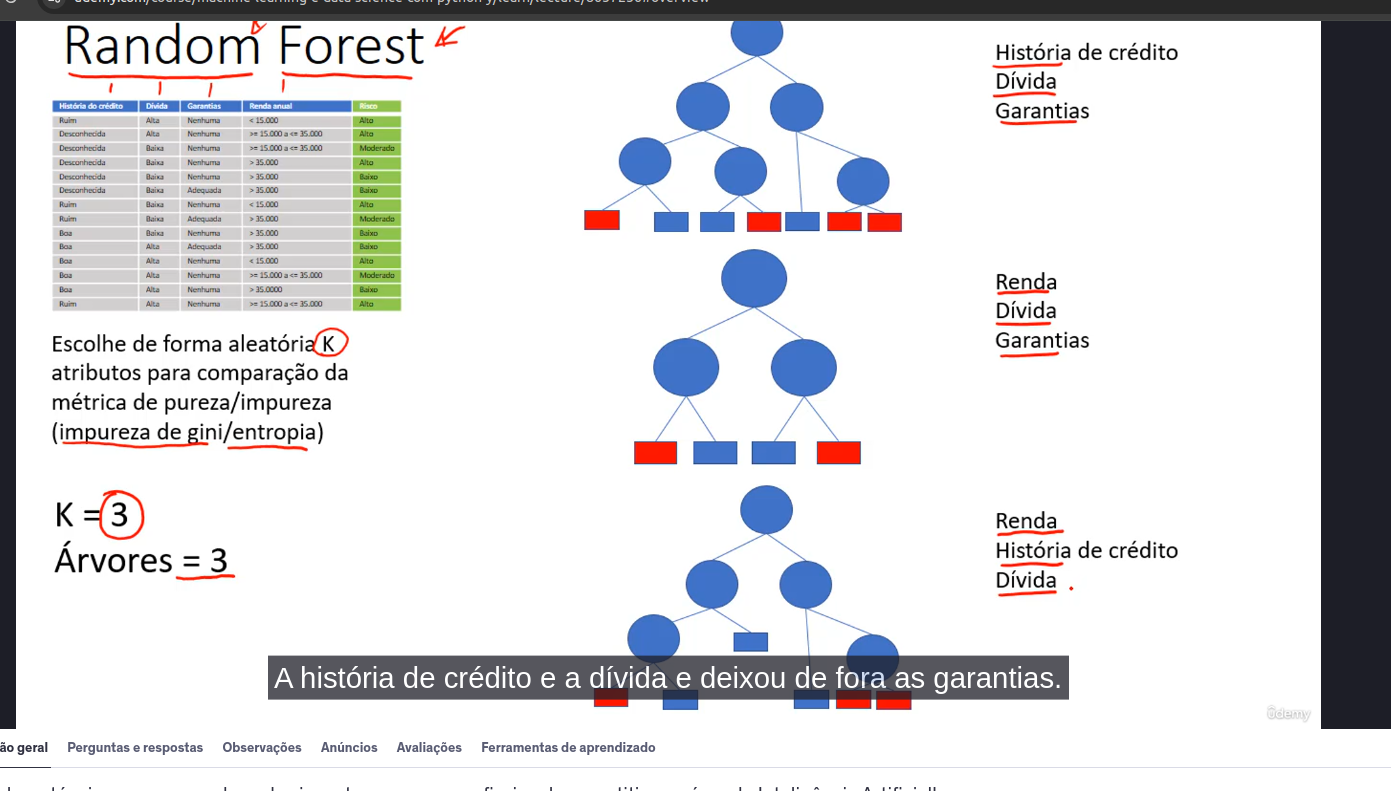


Se não divulgarmos os números dos atributos (K) no parâmetro, o padrão vai ser calculado como raiz quadrada das colunas

temos 4 colunas e sua raizquadrada(4) é de 2; 

As árvores vão ser geradas com os 2 atributos ou colunas aleatórias em cada árvore. 





## Outro método é tirar o logaritmo. 





Exemplo: Método random forest para interpretar o movimento random kinect (vídeo game com base em movimentos das pessoas - esporte ou dança)

Artigo: Real-Time Human Pose Recognition in Parts from Single Depth Images. 

# 5.1) Random Forest - base de crédito


Gerar várias árvores de decisão. 

ensemble concatena vários algoritmos


#coleção de várias árvores de decisão
# biblioteca de conjunto de algoritmos
from sklearn.ensemble import RandomForestClassifier

In [38]:
import pickle
# read =rb 
with open('../2-3-Classificacao/credit_aula.pkl', 'rb') as f:
    X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

In [39]:
#Olhar o shape
# idade, renda e a dívida => x
# somente as classes, paga ou não paga o empréstimo => y
        
X_credit_treinamento.shape, y_credit_treinamento.shape

((24435, 3), (24435,))

3 colunas

*** person_income,	person_age,	loan_amnt

 *** renda, idade, e a dívida

- income é a renda da pessoa (considerada anualmente)

- age

- loan_amnt->Loan amount é a dívida que a pessoa possui

In [40]:
# fazer a avaliação das classes y
X_credit_teste.shape, y_credit_teste.shape

((8146, 3), (8146,))

Olhar o shape

- idade, renda e a dívida => x

 - somente as classes, paga ou não paga o empréstimo => y

#### critério dos parâmetros do RandomForestClassifier

class sklearn.ensemble.RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)

- n_estimators é o número de árvores de decisão que criaremos (valor padrão 100)

se criados 100 árvores  de decisão, e 30 classificados como vai pagar e 70 como não vai pagar, o resultado final não vai pagar, pois classifica com o voto da maioria

- criterion = 'gini' ou 'entropy'

manter a mesma ideia das aulas teoricas. 


- random_state = 0, pode ser qualquer 1, mas é só para gerarmos sempre o mesmo resultado

In [41]:
random_forest_credit = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state = 0)
random_forest_credit.fit(X_credit_treinamento, y_credit_treinamento)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [42]:
# treinamento feito, olhar o parâmetros utilizados
print(random_forest_credit.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 10, 'n_jobs': None, 'oob_score': False, 'random_state': 0, 'verbose': 0, 'warm_start': False}


In [43]:
# gerar as previsões
previsoes = random_forest_credit.predict(X_credit_teste)
previsoes[:500]

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,

In [44]:
#comparação com os dados reais
y_credit_teste[:500]

array([0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,

-> 0 classificado como paga

-> 1 classificado como não paga

In [45]:
from sklearn.metrics import accuracy_score, classification_report

# acurácia dos dados, valor real com o previsto

accuracy = accuracy_score(y_credit_teste, previsoes)

print(f'A accuracy_score ou a taxa de acerto é de {accuracy*100:.2f} %') 
# comparando com a outra árvore de decisão da base de crédito -> 3-2_Arvore_decisao_parte3_basecredito.ipynb
# a acurácia foi de 81.57 %.

A accuracy_score ou a taxa de acerto é de 83.80 %


0.8379572796464523

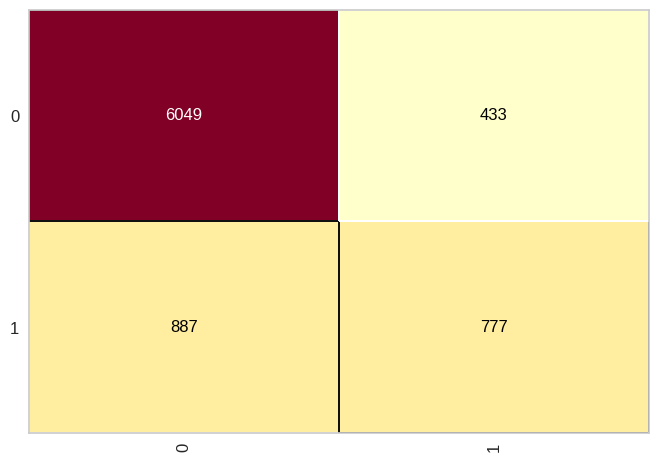

In [46]:
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(random_forest_credit)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)

### mudar os parâmetros para melhorar ainda mais os parâmetros

In [47]:
# quanto mais árvores de dados mencionarmos maior será o tempo do nosso processo.
# há necessidade de fazer testes. nem sempre ter mais árvores terá o melhor resultado.  
# n_estimators=40 ou 30 dá o mesmo valor de 84,21%
random_forest_credit = RandomForestClassifier(n_estimators=30, criterion='entropy', random_state = 0)
random_forest_credit.fit(X_credit_treinamento, y_credit_treinamento)
# treinamento feito, olhar o parâmetros utilizados
print(random_forest_credit.get_params())
previsoes = random_forest_credit.predict(X_credit_teste)

#from sklearn.metrics import accuracy_score, classification_report
# acurácia dos dados, valor real com o previsto
accuracy = accuracy_score(y_credit_teste, previsoes)
print(f'A accuracy_score ou a taxa de acerto é de {accuracy*100:.2f} %') 
# comparando com a outra árvore de decisão da base de crédito -> 3-2_Arvore_decisao_parte3_basecredito.ipynb
# a acurácia foi de 81.57 %.

# depende do tipo de execução também

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 30, 'n_jobs': None, 'oob_score': False, 'random_state': 0, 'verbose': 0, 'warm_start': False}
A accuracy_score ou a taxa de acerto é de 84.21 %


0.8421311072919224

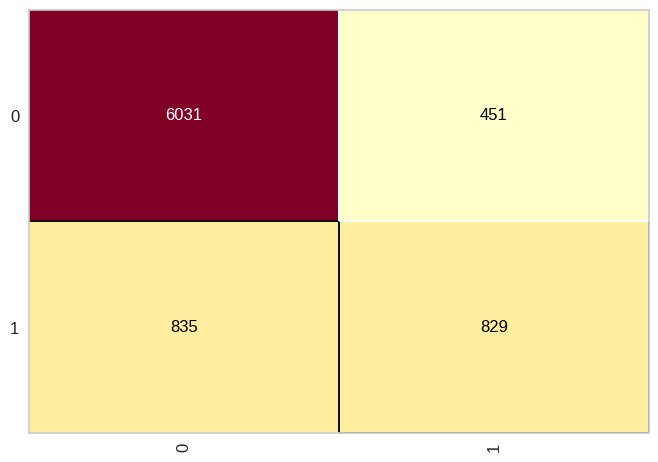

In [48]:
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(random_forest_credit)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)

Olhar o desempenho

Acerto os que pagam muito de 6031 (0)

e os que não pagam 829 (1) melhorou


In [50]:
# porém na árvore de decisão simples seria melhor a avaliação ou previsão dos que não pagam (1)
# para o banco é mais importante.

In [51]:
print(classification_report(y_credit_teste, previsoes))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      6482
           1       0.65      0.50      0.56      1664

    accuracy                           0.84      8146
   macro avg       0.76      0.71      0.73      8146
weighted avg       0.83      0.84      0.83      8146




o 0 paga identifica bem, com 93% de recall, e com uma precisão de 88%

o 1 de não paga, identifica bem, com 50% de recall, e com uma precisão de 65%.